# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [12]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [13]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    B, C, H, W = x.shape
    P = patch_size
    
    h_p1, w_p1 = H // P, W // P
    x = x.reshape(B, C, h_p1, P, w_p1, P)
    x = x.permute(0, 2, 4, 1, 5, 3)    # (B, h_p1, w_p1, C, P, P)
    x = x.reshape(B, h_p1 * w_p1, C * P * P)  # (B, N, patch_dim)
    return x

In [14]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int): # patch_dim = C * P * P
        super().__init__()
        self.proj = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return self.proj(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, num_tokens, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_emb

In [15]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.w1(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = self.w2(x)
        x = self.drop(x)
        return x


class GLUFeedForward(nn.Module): #
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        self.variant = variant
        self.w_gate = nn.Linear(d_model, d_ff_gated)
        self.w_val  = nn.Linear(d_model, d_ff_gated)
        self.w2     = nn.Linear(d_ff_gated, d_model)
        self.drop   = nn.Dropout(dropout)

        if variant == "geglu":
            self.act = F.gelu
        elif variant == "swiglu":
            self.act = F.silu   # SiLU = Swish-1
        else:
            raise ValueError(f"Unknown GLU variant: {variant}")


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate = self.act(self.w_gate(x))
        val  = self.w_val(x)

        x = gate * val
        x = self.drop(x)
        x = self.w2(x)
        x = self.drop(x)
        return x

In [16]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.mlp  = mlp
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_norm = self.ln1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + self.drop1(attn_out)

        x = x + self.drop2(self.mlp(self.ln2(x)))
        return x

In [17]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # TODO: implement a strategy for embedding the patches
        self.patch_embed = PatchEmbed(patch_dim, d_model)
        self.pos_embed   = PositionalEmbedding(self.num_tokens, d_model)

        # TODO: implement a strategy to select the right mlp version for your experiment

        if mlp_kind == "ffn":
            mlp = FeedForward(d_model, d_ff, dropout)
        else:
            d_ff_gated = int(2 * d_ff / 3)
            mlp = GLUFeedForward(d_model, d_ff_gated, dropout, variant=mlp_kind)


        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=mlp, # TODO: Feed your mlp to the encoder blocks
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patches = patchify(x, self.patch_size)
        tok = self.patch_embed(patches)
        tok = self.pos_embed(tok)
        
        for blk in self.blocks: tok = blk(tok)
        tok = self.norm(tok)
        pooled = tok.mean(dim=1)
        logits = self.head(pooled)
        return logits

In [27]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 1
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [28]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            # loss = ... # TODO: Your criterion
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        # TODO: Return your metrics that you think will support your claim for this experiment
        "mlp_kind": mlp_kind,
        "train_losses": train_losses,
        "test_accs": test_accs,
        "best_acc": max(test_accs),
        "final_acc": test_accs[-1]
    }

In [29]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["ffn", "geglu", "swiglu"]
results = []

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)


Run: ffn | 
[ffn] epoch 1/5 | test acc: 0.8014
[ffn] epoch 2/5 | test acc: 0.9028
[ffn] epoch 3/5 | test acc: 0.9266
[ffn] epoch 4/5 | test acc: 0.9412
[ffn] epoch 5/5 | test acc: 0.9450

Run: geglu | 
[geglu] epoch 1/5 | test acc: 0.8455
[geglu] epoch 2/5 | test acc: 0.9217
[geglu] epoch 3/5 | test acc: 0.9385
[geglu] epoch 4/5 | test acc: 0.9483
[geglu] epoch 5/5 | test acc: 0.9576

Run: swiglu | 
[swiglu] epoch 1/5 | test acc: 0.8581
[swiglu] epoch 2/5 | test acc: 0.9253
[swiglu] epoch 3/5 | test acc: 0.9394
[swiglu] epoch 4/5 | test acc: 0.9504
[swiglu] epoch 5/5 | test acc: 0.9538


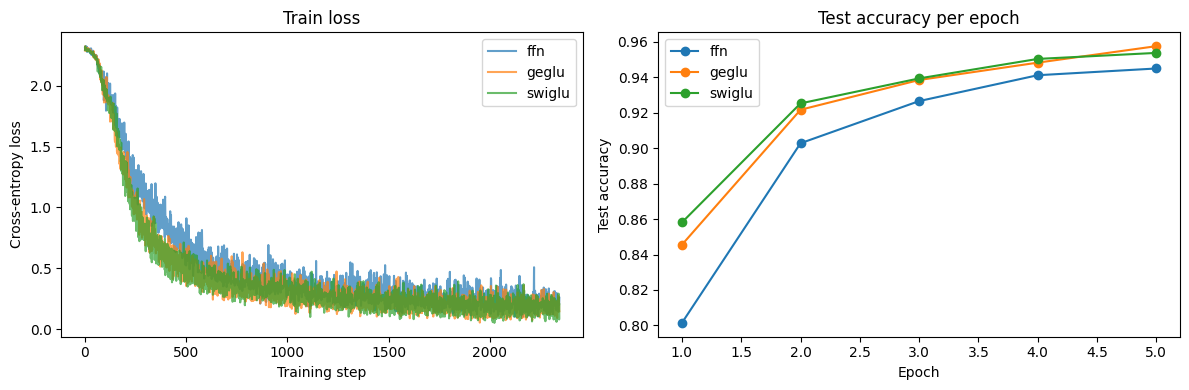


Variant      Best Acc  Final Acc
-------------------------------------------------------
ffn            0.9450     0.9450
geglu          0.9576     0.9576
swiglu         0.9538     0.9538


In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in results:
    axes[0].plot(r["train_losses"], label=r["mlp_kind"], alpha=0.7)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Train loss")
axes[0].legend()

for r in results:
    axes[1].plot(range(1, len(r["test_accs"]) + 1), r["test_accs"], marker="o", label=r["mlp_kind"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Test accuracy per epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print(f"{'Variant':<10} {'Best Acc':>10} {'Final Acc':>10}")
print("-" * 55)
for r in results:
    print(f"{r['mlp_kind']:<10} {r['best_acc']:>10.4f} {r['final_acc']:>10.4f}")
print("=" * 55)